# Week 11: DBSCAN and Hierarchical Agglomerative Clustering

## Setup and Data Loading

Importing libraries needed for DBSCAN and hierarchical agglomerative clustering, including tools for dendrograms, and loading the scaled diabetes dataset used throughout this capstone.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

df = pd.read_csv('diabetes_binary_5050split_health_indicators_BRFSS2015.csv')

X = df.drop('Diabetes_binary', axis=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(70692, 21)


## Creating a Sample for DBSCAN and HAC

DBSCAN and hierarchical agglomerative clustering are computationally expensive on large datasets, and a dendrogram with tens of thousands of leaves would be unreadable. Taking a random sample of 1,000 rows keeps the analysis meaningful while making both algorithms and the dendrogram visualization actually usable.

In [2]:
np.random.seed(42)
sample_indices = np.random.choice(X_scaled.shape[0], size=1000, replace=False)
X_sample = X_scaled[sample_indices]

print(X_sample.shape)

(1000, 21)


## DBSCAN Clustering

Running DBSCAN on the sampled data with initial epsilon and MinPts values, following the two-parameter approach described in this week's lesson, then checking how many clusters and how many noise points result.

In [3]:
dbscan = DBSCAN(eps=3, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_sample)

n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print(f"Number of clusters: {n_clusters}")
print(f"Number of noise points: {n_noise}")
print(f"Percentage classified as noise: {n_noise / len(dbscan_labels) * 100:.1f}%")

Number of clusters: 5
Number of noise points: 381
Percentage classified as noise: 38.1%


## Tuning Epsilon

The initial epsilon value produced a high noise percentage (38.1%), consistent with the lesson's warning that a small epsilon creates tight neighborhoods and labels too many points as noise. Testing a range of epsilon values to find one that produces a more reasonable balance between clusters and noise.

In [4]:
eps_values = [2, 3, 4, 5, 6, 7, 8]

for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=5)
    labels = dbscan.fit_predict(X_sample)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    noise_pct = n_noise / len(labels) * 100
    print(f"eps={eps}: {n_clusters} clusters, {n_noise} noise points ({noise_pct:.1f}%)")

eps=2: 20 clusters, 747 noise points (74.7%)
eps=3: 5 clusters, 381 noise points (38.1%)
eps=4: 8 clusters, 110 noise points (11.0%)
eps=5: 2 clusters, 22 noise points (2.2%)
eps=6: 2 clusters, 4 noise points (0.4%)
eps=7: 1 clusters, 3 noise points (0.3%)
eps=8: 1 clusters, 0 noise points (0.0%)


## Final DBSCAN Model (eps=5)

Selecting eps=5 as the final DBSCAN parameter, since it produces a low noise percentage (2.2%) while still finding meaningful structure (2 clusters), matching the 2-cluster result found by k-means in Week 10. Profiling the resulting clusters against key health indicators and actual diabetes diagnosis.

In [5]:
final_dbscan = DBSCAN(eps=5, min_samples=5)
dbscan_labels = final_dbscan.fit_predict(X_sample)

df_sample = df.iloc[sample_indices].copy()
df_sample['DBSCAN_Cluster'] = dbscan_labels

print(df_sample['DBSCAN_Cluster'].value_counts())
print()
print(df_sample.groupby('DBSCAN_Cluster')[['BMI', 'Age', 'GenHlth', 'HighBP', 'Diabetes_binary']].mean())

DBSCAN_Cluster
 0    963
-1     22
 1     15
Name: count, dtype: int64

                      BMI       Age   GenHlth    HighBP  Diabetes_binary
DBSCAN_Cluster                                                          
-1              29.000000  8.000000  3.090909  0.636364         0.545455
 0              29.359294  8.782970  2.854621  0.561786         0.501558
 1              27.333333  6.866667  2.133333  0.133333         0.133333


## Hierarchical Agglomerative Clustering (HAC)

Building a dendrogram using Ward's linkage on the sampled data to visualize the full hierarchy of merges, following the dendrogram approach from this week's lesson, and comparing the resulting structure to both k-means and DBSCAN.

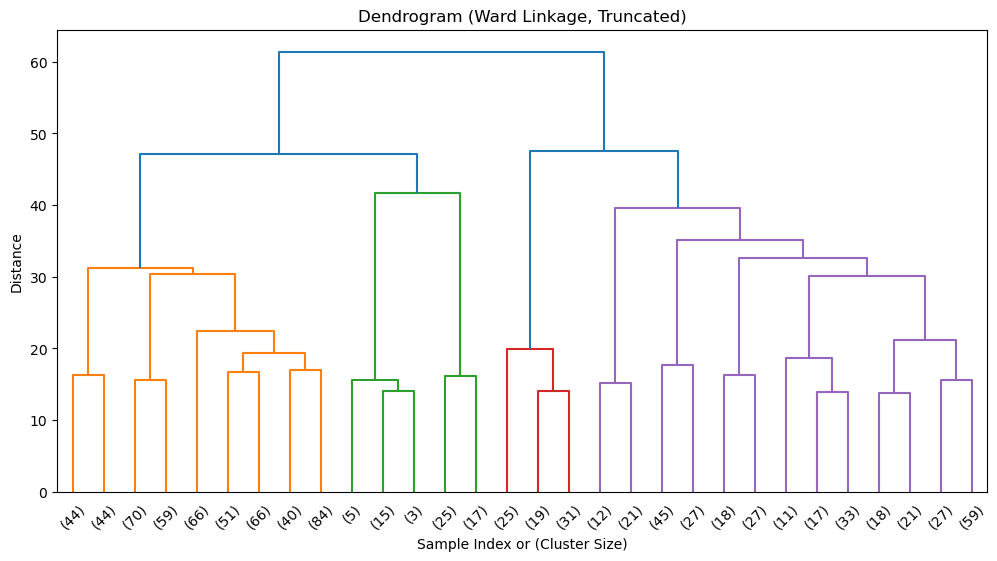

In [6]:
linked = linkage(X_sample, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(linked, truncate_mode='lastp', p=30, show_leaf_counts=True)
plt.xlabel('Sample Index or (Cluster Size)')
plt.ylabel('Distance')
plt.title('Dendrogram (Ward Linkage, Truncated)')
plt.savefig('week11_dendrogram.png', dpi=300, bbox_inches='tight')
plt.show()

## HAC at 2 Clusters

Cutting the dendrogram at 2 clusters (matching the k-means and DBSCAN cluster count) to directly compare how HAC's grouping compares to the other two clustering methods on the same sampled data.

In [7]:
hac = AgglomerativeClustering(n_clusters=2, linkage='ward')
hac_labels = hac.fit_predict(X_sample)

df_sample['HAC_Cluster'] = hac_labels

print(df_sample['HAC_Cluster'].value_counts())
print()
print(df_sample.groupby('HAC_Cluster')[['BMI', 'Age', 'GenHlth', 'HighBP', 'Diabetes_binary']].mean())

HAC_Cluster
1    589
0    411
Name: count, dtype: int64

                   BMI       Age   GenHlth    HighBP  Diabetes_binary
HAC_Cluster                                                          
0            30.834550  9.472019  3.510949  0.720195         0.681265
1            28.264856  8.224109  2.387097  0.443124         0.368421


## Summary: Comparing All Three Clustering Methods

K-means, DBSCAN, and HAC (Ward linkage) were all tested on this dataset. K-means and HAC produced structurally similar results: reasonably balanced splits with a substantial diabetes rate gap between the high-risk and low-risk groups (K-means: 75% vs 37%; HAC: 68% vs 37%). DBSCAN produced a structurally different result: one dominant cluster containing 96% of points, one small distinct cluster of unusually low-risk individuals (13% diabetes rate), and a small noise category. This makes sense given how each algorithm defines a cluster: k-means and Ward's linkage HAC both explicitly minimize variance and favor balanced, spherical groupings, while DBSCAN groups purely by density and has no bias toward evenly sized clusters. This is a valuable finding for understanding this dataset: the "right" number of clusters (2) is consistent across methods, but what those 2 clusters actually represent depends heavily on which clustering algorithm is used.